In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# 1️⃣ 读取长时ECG文件
df = pd.read_csv("ecg_data.txt", names=["t", "val"])
df = df.dropna().reset_index(drop=True)

# 2️⃣ 基本统计
n_samples = len(df)
duration = df["t"].iloc[-1] - df["t"].iloc[0]
dt = np.diff(df["t"])
fs = 1 / np.median(dt)

print(f"Samples: {n_samples}")
print(f"Duration: {duration/3600:.2f} hours")
print(f"Estimated sampling rate: {fs:.2f} Hz")

Samples: 1531146
Duration: 8.65 hours
Estimated sampling rate: 49.66 Hz


In [88]:
def bandpass_filter(x, fs, low=0.5, high=20, order=3):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, x)

filtered = bandpass_filter(df["val"], fs)
df["filtered"] = filtered

# 异常值清洗
val = df['val'].to_numpy()

# Step 1: 计算主要分布区间（排除极端值）
low, high = np.percentile(val, [1, 99.5]) 
print(f"清洗范围: {low:.1f} ~ {high:.1f}")

# Step 2: 创建掩码并筛选
mask = (val >= low) & (val <= high)
df_clean = df[mask].copy()
df_clean.index = np.arange(df_clean.shape[0])
#df[~mask].hist()
#df[mask].describe()

# ⚙️ 自适应阈值：取信号90百分位
height_thr = np.percentile(df_clean["filtered"], 90)
min_dist = int(0.4 * fs)  # 0.4秒间隔

# 🔍 检测R波峰
peaks, _ = find_peaks(df_clean["filtered"], height=height_thr, distance=min_dist)
df_clean["is_peak"] = np.zeros(df_clean.shape[0])
df_clean.loc[peaks, "is_peak"] = 1
print(len(peaks))


清洗范围: 226.0 ~ 504.0
33503


Duration: 8.65 hours
Estimated sampling rate: 49.66 Hz
Mean HR: 65.4 bpm
SDNN: 0.1232 s
RMSSD: 0.0882 s


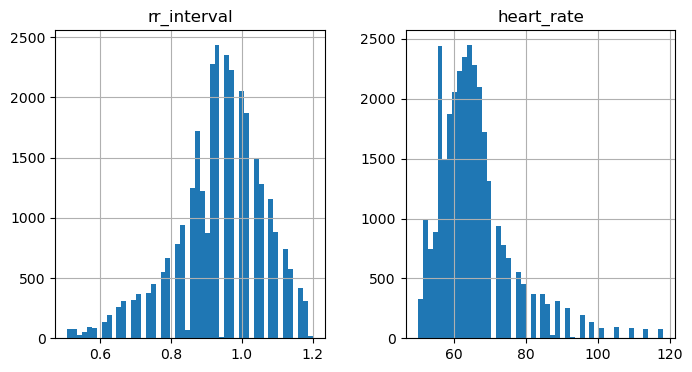

In [103]:
peak_times = df_clean["t"].values[peaks]
rr = np.diff(peak_times)

# 原始 HR
hr = 60 / rr
rr_clean = rr[(rr > 0.5) & (rr < 1.2)]
rr_clean = rr_clean[np.abs(np.diff(rr_clean, prepend=rr_clean[0])) < 0.3]
hr_clean = 60 / rr_clean
rr_hr = pd.DataFrame([rr_clean, hr_clean]).T
rr_hr.columns = ['rr_interval', 'heart_rate']

rr = rr_hr['rr_interval']
hr = rr_hr['heart_rate']

rr_hr.hist(bins=50, figsize=(8, 4))

print(f"Duration: {duration/3600:.2f} hours")
print(f"Estimated sampling rate: {fs:.2f} Hz")
print(f"Mean HR: {np.mean(hr_clean):.1f} bpm")
print(f"SDNN: {np.std(rr_clean, ddof=1):.4f} s")
print(f"RMSSD: {np.sqrt(np.mean(np.diff(rr)**2)):.4f} s")

### 计算清洗后 HRV

In [102]:
mean_rr = np.mean(rr_clean)
sdnn = np.std(rr_clean, ddof=1)
rmssd = np.sqrt(np.mean(np.diff(rr_clean)**2))
mean_hr = 60 / mean_rr

print(f"After cleaning:")
print(f"Mean HR: {mean_hr:.1f} bpm")
print(f"SDNN: {sdnn:.4f} s")
print(f"RMSSD: {rmssd:.4f} s")


After cleaning:
Mean HR: 64.1 bpm
SDNN: 0.1232 s
RMSSD: 0.0882 s


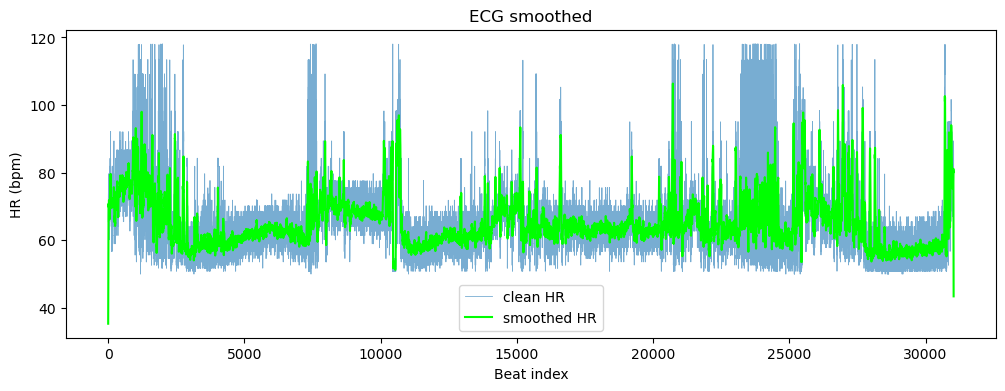

In [98]:
# 平滑HR曲线
hr_clean = 60 / rr_clean
window = 20  # 平滑窗口
hr_smooth = np.convolve(hr_clean, np.ones(window)/window, mode='same')

plt.figure(figsize=(12,4))
plt.plot(hr_clean, lw=0.6, alpha=0.6, label="clean HR")
plt.plot(hr_smooth, lw=1.5, color="lime", label="smoothed HR")
plt.xlabel("Beat index")
plt.ylabel("HR (bpm)")
plt.legend()
plt.title('ECG smoothed')
plt.savefig('HR_smooth.jpg', dpi=500)

### 🧩 Block B — 在 HR 曲线中标出异常点

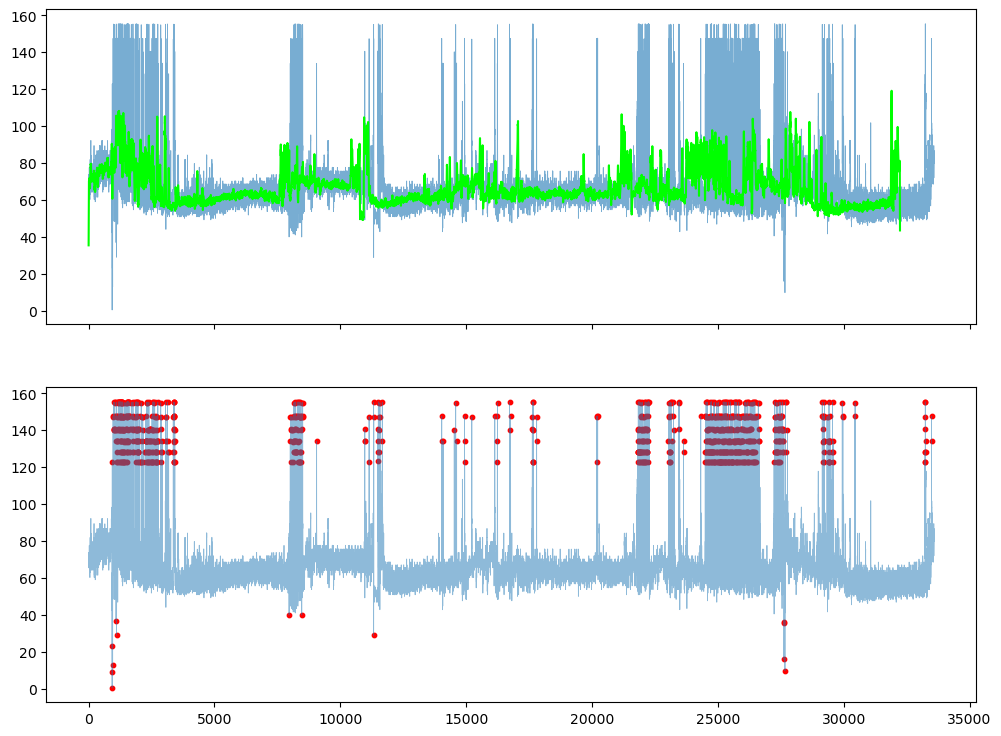

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(12,9), sharex=True, sharey=True)

axes[0].plot(hr_all, lw=0.6, alpha=0.6, label="clean HR")
axes[0].plot(hr_smooth, lw=1.5, color="lime", label="smoothed HR")
axes[1].plot(hr_all, lw=0.6, alpha=0.5, label="Instant HR")
axes[1].scatter(np.where(abnormal)[0], hr_all[abnormal], c='red', s=10, label="Abnormal HR")

### 🧩 Block C — 输出异常区间时间范围

In [26]:
peak_times = df["t"].values[peaks]
abnormal_times = peak_times[1:][abnormal]  # 对应异常RR的时间点

# 分组连续异常，输出起止时间
abnormal_groups = []
if len(abnormal_times) > 0:
    start = abnormal_times[0]
    for i in range(1, len(abnormal_times)):
        if abnormal_times[i] - abnormal_times[i-1] > 10:  # 间隔>10s 视为新段
            abnormal_groups.append((start, abnormal_times[i-1]))
            start = abnormal_times[i]
    abnormal_groups.append((start, abnormal_times[-1]))

print("异常片段时间段（秒）:")
for start, end in abnormal_groups[:10]:  # 只列前10段
    print(f"{start:.1f} - {end:.1f}")


异常片段时间段（秒）:
763.5 - 763.5
961.9 - 972.9
990.4 - 990.4
1003.1 - 1003.5
1020.3 - 1020.7
1033.7 - 1051.8
1088.7 - 1138.1
1149.6 - 1163.4
1174.6 - 1322.6
1359.6 - 1417.5


共检测到 1 段连续异常，总删除 1050 个点


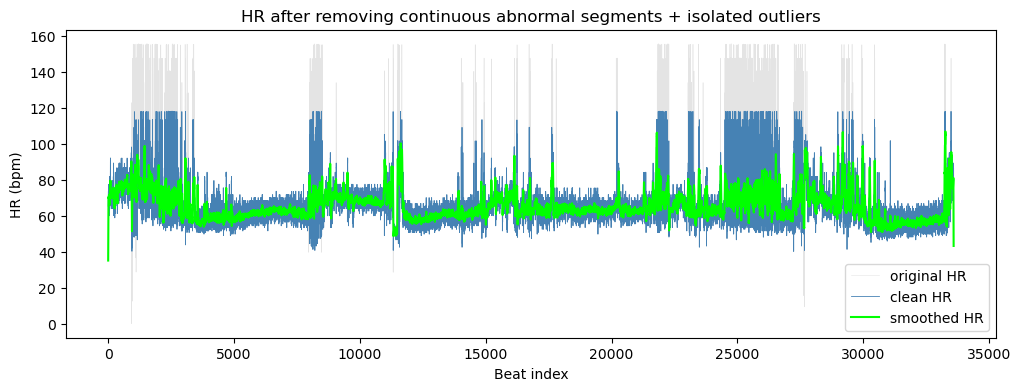

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

hr_all = 60 / rr

# Step 1: 先标出基本异常（单点阈值）
point_mask = (hr_all > 40) & (hr_all < 120)

# Step 2: 找出连续异常段（至少5个连续异常）
min_len = 5
bad_idx = np.where(~point_mask)[0]
bad_groups = []
if len(bad_idx) > 0:
    start = bad_idx[0]
    for i in range(1, len(bad_idx)):
        if bad_idx[i] - bad_idx[i-1] > 1:
            if bad_idx[i-1] - start + 1 >= min_len:
                bad_groups.append((start, bad_idx[i-1]))
            start = bad_idx[i]
    if bad_idx[-1] - start + 1 >= min_len:
        bad_groups.append((start, bad_idx[-1]))

# Step 3: 构建最终mask
final_mask = point_mask.copy()
for s, e in bad_groups:
    final_mask[s:e+1] = False

print(f"共检测到 {len(bad_groups)} 段连续异常，总删除 {np.sum(~final_mask)} 个点")

# Step 4: 生成干净信号和平滑曲线
hr_clean = hr_all[final_mask]
window = 20
hr_smooth = np.convolve(hr_clean, np.ones(window)/window, mode='same')

# Step 5: 绘图
plt.figure(figsize=(12,4))
plt.plot(hr_all, lw=0.4, color='lightgray', alpha=0.6, label='original HR')
plt.plot(np.where(final_mask)[0], hr_clean, lw=0.6, color='steelblue', label='clean HR')
plt.plot(np.where(final_mask)[0], hr_smooth, lw=1.5, color='lime', label='smoothed HR')

# 高亮整段删除区
for s, e in bad_groups:
    plt.axvspan(s, e, color='red', alpha=0.1, lw=0)

plt.xlabel("Beat index")
plt.ylabel("HR (bpm)")
plt.legend()
plt.title("HR after removing continuous abnormal segments + isolated outliers")
plt.show()
